In [2]:
import pennylane as qml
from scipy.linalg import expm 
from pennylane import numpy as np

In [21]:
num_qubits =11
sys_size = 5
dev = qml.device('default.qubit', wires=num_qubits)
@qml.qnode(dev)
def Fidelity(O1,O2):
    qml.QubitUnitary(O1, wires=range(sys_size))
    qml.QubitUnitary(O2, wires=range(sys_size,num_qubits-1))
    qml.Hadamard(wires=num_qubits)
    qml.Barrier()
    for i in range(sys_size):
        qml.ctrl(qml.SWAP(wires=(i,i+sys_size)), control=num_qubits)
    qml.Hadamard(wires=num_qubits)
    return qml.expval(qml.Z(wires=num_qubits))

In [22]:
O1 = np.random.uniform(0,1, size=(2**sys_size, 2**sys_size))
O2 = np.random.uniform(0,1, size=(2**sys_size, 2**sys_size))
O1 = O1*O1.T
O2 = O2*O2.T
O1 = expm(1j*O1)
O1 = expm(1j*O1)

(<Figure size 1100x1200 with 1 Axes>, <Axes: >)


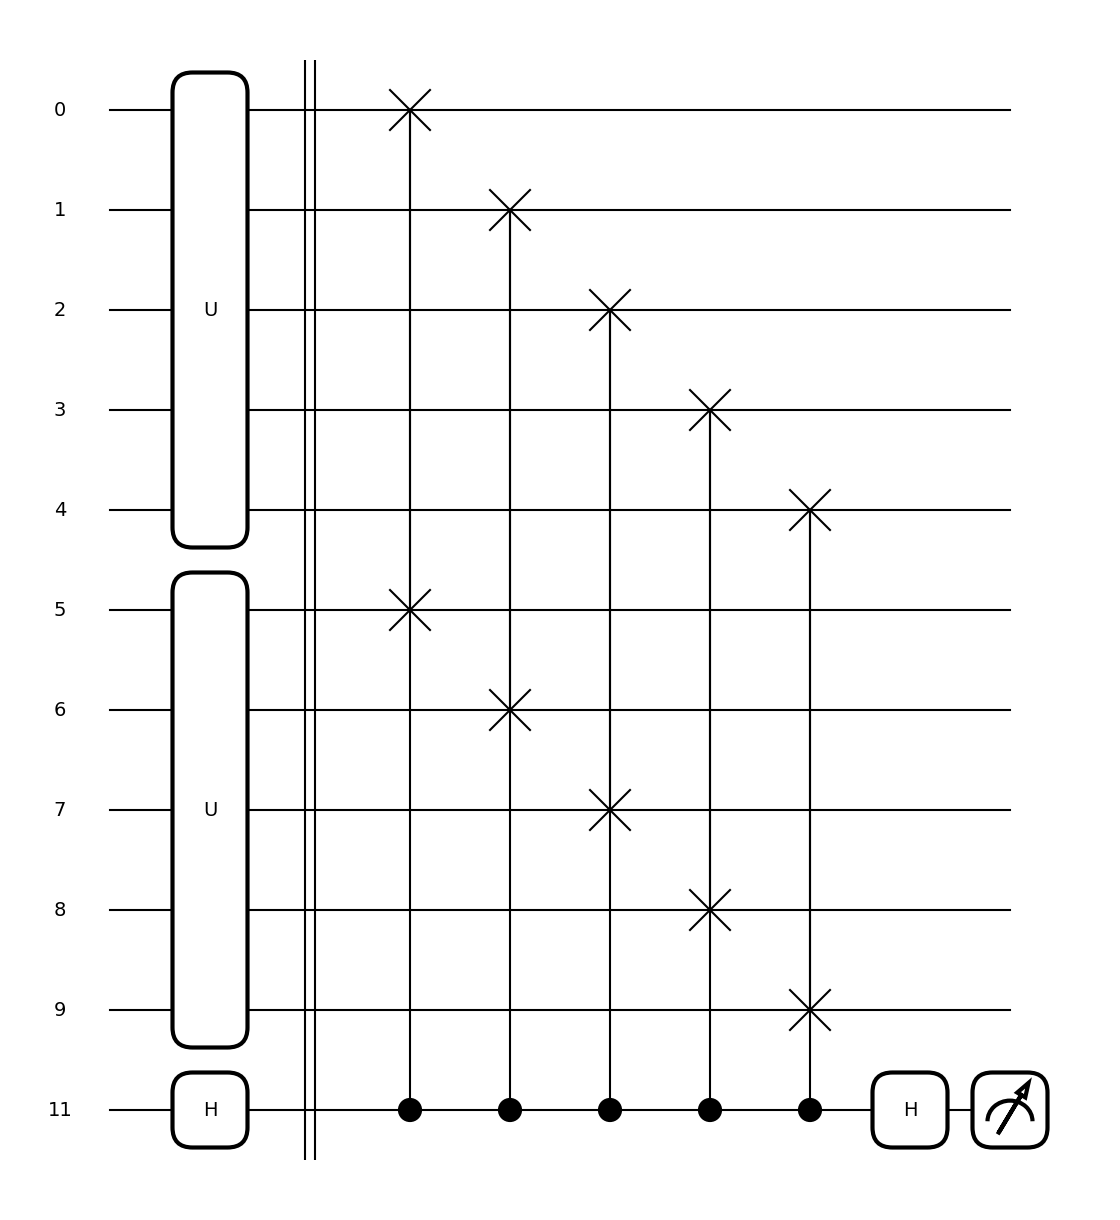

In [23]:
circuit = qml.QNode(Fidelity,dev)
print(qml.draw_mpl(circuit)(O1,O2))

In [24]:
np.allclose(O1,O2)

False

In [25]:
l = circuit(O1,O2)
print(l)

WireError: Cannot run circuit(s) on default.qubit as they contain wires not found on the device: {11}

In [ ]:
l = circuit(O1,Oq)
print(l)